In [108]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import os

# --- Dynamic image loader with fallback ---
def get_image_path(player_name):
    base = "/Users/nerdysoccer/Documents/player_images/"
    filename = player_name + ".png"
    path = base + filename

    # If the image exists, use it. Otherwise, fallback.
    if os.path.exists(path):
        return path
    else:
        return base + "default.png"   # <-- your fallback image

In [109]:
file_path = r"/Users/nerdysoccer/Documents/MLS_Player_Stats_2026.xlsx"
df = pd.read_excel(file_path, sheet_name='Player Stats')

In [110]:
df["player_name"] = df['player_first_name'].fillna("") + " " + df['player_last_name'].fillna("")

In [111]:
###Where you put in the players names###
p1 = "Leo Messi"
p2 = "Petar Musa"

player1 = df[df["player_name"] == p1].squeeze()
player2 = df[df["player_name"] == p2].squeeze()

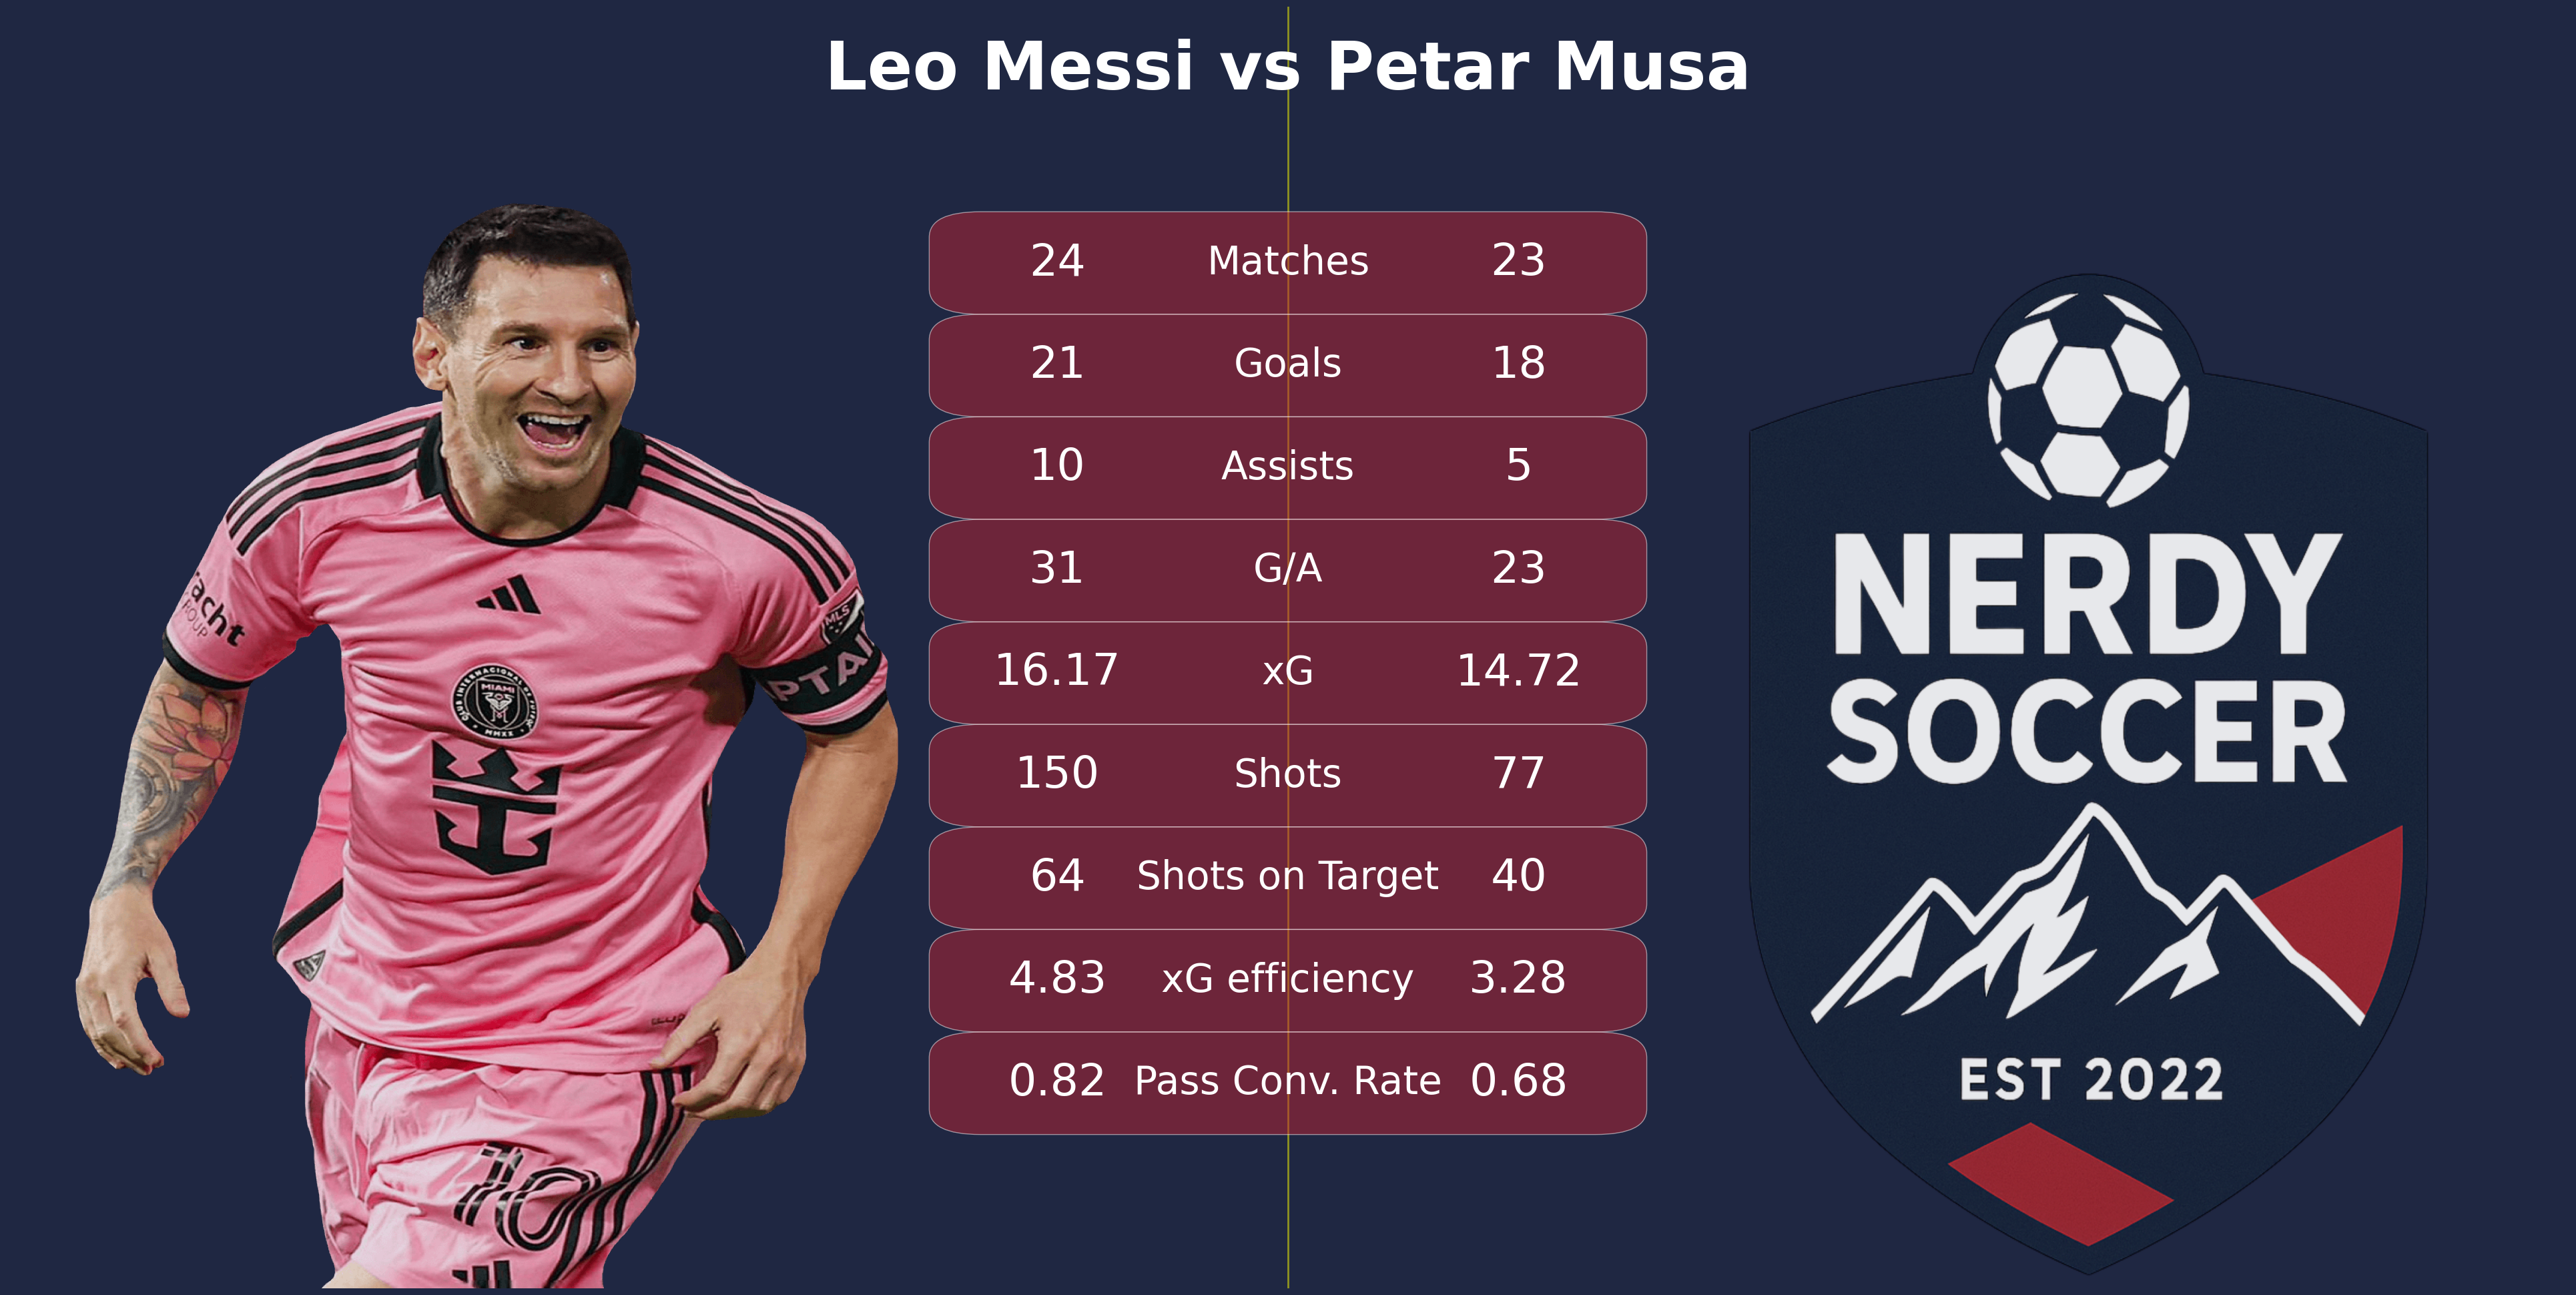

In [185]:
# States dictionary
stats = {
    "Matches": [player1["matches_played"], player2["matches_played"]],
    "Goals": [player1["goals"], player2["goals"]],
    "Assists": [player1["assists"], player2["assists"]],
    "G/A": [player1["goals_plus_assists"], player2["goals_plus_assists"]],
    "xG": [f"{player1['xG']:.2f}", f"{player2['xG']:.2f}"],
    "Shots": [player1["shots_at_goal_sum"], player2["shots_at_goal_sum"]],
    "Shots on Target": [player1["shots_on_target"], player2["shots_on_target"]],
    "xG efficiency": [f"{player1['xG_efficiency']:.2f}", f"{player2['xG_efficiency']:.2f}"],
    "Pass Conv. Rate": [player1["passes_conversion_rate"], player2["passes_conversion_rate"]]
}

# --- Figure & main overlay axes ---
fig = plt.figure(figsize=(38.4,21.6), dpi=100, facecolor="#1F2742")
ax_main = fig.add_axes([0, 0, 1, 1])
ax_main.axis("off")
ax_main.set_facecolor("#1F2742")
ax_main.set_xlim(-1.0, 1)
ax_main.set_ylim(0, 1)

# --- Load images dynamically ---
img1 = plt.imread(get_image_path(p1))
img2 = plt.imread(get_image_path(p2))

# --- Draw images INDISE ax_main (background)
ax_main.imshow(img1, extent=[-0.95, -0.30, -0.05, 0.85], zorder=0, alpha=0.90)
ax_main.imshow(img2, extent=[0.30, .95, -0.05, 0.85], zorder=0, alpha=0.90)


# Title (use ax_main)
ax_main.text(0, .95, f"{p1} vs {p2}",
             ha="center", va="center", fontsize=72,
             fontweight="bold", color="#FFFFFF", zorder=10)

# Bubble settings
bubble_left = 0.38
bubble_width = 0.24
bubble_height = 0.04

# Text positions relative to bubble
p1_x = bubble_left + 0.03
stat_x = bubble_left + (bubble_width / 2)
p2_x = bubble_left + bubble_width - 0.03

# Bubble Stat rows
y = 0.80

for stat, values in stats.items():

    bubble = FancyBboxPatch(
        (bubble_left, y - bubble_height/2),
        bubble_width,
        bubble_height,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=1,
        edgecolor="#FFFFFF",
        facecolor="#BB2533",
        alpha=0.50,
        transform=ax_main.transAxes,
        zorder=10
    )

    ax_main.add_patch(bubble)

    ax_main.text(
        p1_x,
        y,
        str(values[0]),
        fontsize=48,
        color="#FFFFFF",
        ha="center",
        va="center",
        transform=ax_main.transAxes,
        zorder=10
    )

    ax_main.text(
        stat_x,
        y,
        stat,
        fontsize=42,
        color="#FFFFFF",
        ha="center",
        va="center",
        transform=ax_main.transAxes,
        zorder=10
    )

    ax_main.text(
        p2_x,
        y,
        str(values[1]),
        fontsize=48,
        color="#FFFFFF",
        ha="center",
        va="center",
        transform=ax_main.transAxes,
        zorder=10
    )

    y -= 0.08


ax_main.axvline(
    x=0.0,
    color="yellow",
    linewidth=2,
    alpha=0.5
)

plt.savefig("player_comparison.png", dpi=100, facecolor="#1F2742", bbox_inches=None)